##

In [2]:
#1. Import numpy as np, pandas as pd, and matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#2. Load 2015_16_Districtwise.csv into a DataFrame called df using pd.read_csv()
df = pd.read_csv("2015_16_Districtwise.csv.zip")

**Exercise 21** – Quantifying the Gender Literacy Gap

In [3]:
#81. Create a column LIT_GENDER_GAP = male literacy - female literacy for every district.
df["LIT_GENDER_GAP"] = df["MALE_LIT"] - df["FEMALE_LIT"]
df.head()

,AC_YEAR,STATCD,DISTCD,STATNAME,DISTNAME,DISTRICTS,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,...,UUNI_SC,UUNI_ST,TOTCLS1G,TOTCLS2G,TOTCLS3G,TOTCLS4G,TOTCLS5G,TOTCLS6G,TOTCLS7G,LIT_GENDER_GAP
0,2015-16,1,101,JAMMU & KASHMIR,KUPWARA,1,13,391,104,875564.0,...,26,2594,3489,5315,27,62,23,852,239,22.31
1,2015-16,1,102,JAMMU & KASHMIR,BARAMULA,1,18,678,144,1015503.0,...,0,1571,4127,5800,210,53,30,1665,360,22.34
2,2015-16,1,103,JAMMU & KASHMIR,SRINAGAR,1,8,94,65,1269751.0,...,31,408,817,3284,886,11,0,2873,40,14.48
3,2015-16,1,104,JAMMU & KASHMIR,BADGAM,1,13,523,104,735753.0,...,18,857,2290,3837,119,45,8,1035,325,21.96
4,2015-16,1,105,JAMMU & KASHMIR,PULWAMA,1,8,359,64,570060.0,...,17,855,1688,2584,151,67,5,1101,209,21.60


In [7]:
#82. Sort districts by this gap in descending order and display the top 10 (largest male advantage).
top10 = df.sort_values(by="LIT_GENDER_GAP", ascending=False)
print(top10[["STATNAME", "DISTNAME", "LIT_GENDER_GAP"]].head(10))

            STATNAME        DISTNAME  LIT_GENDER_GAP
89           HARYANA           MEWAT           35.40
109        RAJASTHAN  SAWAI MADHOPUR           34.92
108        RAJASTHAN         KARAULI           33.78
117        RAJASTHAN           JALOR           33.10
115        RAJASTHAN       JAISALMER           32.86
121        RAJASTHAN            TONK           32.26
110        RAJASTHAN           Dausa           32.21
17   JAMMU & KASHMIR          RAMBAN           31.93
116        RAJASTHAN          BARMER           31.29
124        RAJASTHAN       RAJSAMAND           31.08


In [8]:
#83. Sort ascending and display the top 10 districts where female literacy exceeds male literacy the most.
bottom10 = df.sort_values(by="LIT_GENDER_GAP")

print(bottom10[["STATNAME", "DISTNAME", "LIT_GENDER_GAP"]].head(10))

       STATNAME          DISTNAME  LIT_GENDER_GAP
312   MEGHALAYA     JAINTIA HILLS           -6.96
294     MIZORAM          SERCHHIP            0.96
292     MIZORAM            AIZAWL            1.01
311   MEGHALAYA  EAST KHASI HILLS            1.11
630      KERALA    PATHANAMTHITTA            1.44
628      KERALA          KOTTAYAM            1.50
665  PUDUCHERRY              MAHE            1.63
272    NAGALAND        MOKOKCHUNG            1.81
291     MIZORAM           KOLASIB            1.97
309   MEGHALAYA  WEST KHASI HILLS            1.99


In [11]:
#84. Compute the average LIT_GENDER_GAP nationally and per state, and report the 3 states with the smallest average gap.
national_avg = df["LIT_GENDER_GAP"].mean()
print("National Average Gap:", national_avg)
state_avg = df.groupby("STATNAME")["LIT_GENDER_GAP"].mean()
print(state_avg.sort_values().head(3))

National Average Gap: 17.06096214511041
STATNAME
MEGHALAYA    3.724286
KERALA       4.247857
MIZORAM      5.558750
Name: LIT_GENDER_GAP, dtype: float64


**Exercise 22** – Multiple Statistics using agg()

In [18]:
# 85. Group by STATNAME and use .agg(['mean','min','max','std']) on the overall literacy column in one call.
result = df.groupby('STATNAME')["OVERALL_LI"].agg(['mean','min','max','std'])
result

,mean,min,max,std
STATNAME,,,,
A & N ISLANDS,83.413333,77.50,88.49,5.542566
ANDHRA PRADESH,67.373077,59.49,74.37,4.941283
ARUNACHAL PRADESH,65.330000,50.67,82.14,8.302853
ASSAM,73.204815,59.36,88.66,6.860465
BIHAR,63.778947,52.49,75.59,6.650253
CHANDIGARH,86.430000,86.43,86.43,NaN
CHHATTISGARH,69.218125,42.67,79.69,9.724062
DADRA & NAGAR HAVELI,77.650000,77.65,77.65,NaN
DAMAN & DIU,85.710000,83.36,88.06,3.323402


In [19]:
# 86. Sort the result by the 'mean' column descending.
print(result.sort_values(by="mean", ascending=False))


                           mean    min    max        std
STATNAME                                                
KERALA                93.648571  88.49  96.93   2.781670
LAKSHADWEEP           92.280000  92.28  92.28        NaN
MIZORAM               89.436250  66.41  98.76  10.385942
PUDUCHERRY            88.142500  80.26  98.35   7.538229
TRIPURA               87.357500  85.41  88.91   1.566469
GOA                   87.190000  85.53  88.85   2.347595
DELHI                 86.734444  82.80  89.38   2.167886
CHANDIGARH            86.430000  86.43  86.43        NaN
DAMAN & DIU           85.710000  83.36  88.06   3.323402
A & N ISLANDS         83.413333  77.50  88.49   5.542566
HIMACHAL PRADESH      82.675000  73.19  89.01   4.575231
MAHARASHTRA           81.204857  63.04  90.90   5.982006
SIKKIM                80.702500  77.39  84.67   3.296800
UTTARAKHAND           80.292308  74.44  85.24   3.913671
TAMIL NADU            79.848333  64.71  92.14   5.933385
NAGALAND              79.108182

In [20]:
# 87. Identify which state has the largest standard deviation (most internal variation between its districts) and 
# which has the smallest.
highest_std = result["std"].idxmax()
lowest_std = result["std"].idxmin()
print("Highest Std:", highest_std)
print("Lowest Std:", lowest_std)

Highest Std: ODISHA
Lowest Std: TRIPURA


In [21]:
# 88. Print a short interpretation of what a high std means for a state's district-level equality in literacy.
# A higher standard deviation means literacy varies a lot between districts in that state.

**Exercise 23** – Pivot Table

In [25]:
#89. Create a pivot table with STATNAME as the index and mean values of overall literacy, total population, and sex ratio as values.
pivot = pd.pivot_table(
    df,
    index="STATNAME",
    values=["OVERALL_LI", "TOTPOPULAT", "SEXRATIO"],
    aggfunc="mean"
)


In [26]:
# 90. Sort the pivot table by mean literacy descending.
pivot = pivot.sort_values(by="OVERALL_LI", ascending=False)
pivot

,OVERALL_LI,SEXRATIO,TOTPOPULAT
STATNAME,,,
KERALA,93.648571,1080.000000,2.384834e+06
LAKSHADWEEP,92.280000,946.000000,6.442900e+04
MIZORAM,89.436250,964.125000,1.363768e+05
PUDUCHERRY,88.142500,1073.500000,3.111160e+05
TRIPURA,87.357500,958.250000,9.177580e+05
GOA,87.190000,969.500000,7.288615e+05
DELHI,86.734444,864.000000,1.861471e+06
CHANDIGARH,86.430000,818.000000,1.054686e+06
DAMAN & DIU,85.710000,781.500000,1.214555e+05


In [27]:
# 91. Round all values in the pivot table to 1 decimal place.
pivot = pivot.round(1)
pivot

,OVERALL_LI,SEXRATIO,TOTPOPULAT
STATNAME,,,
KERALA,93.6,1080.0,2384834.1
LAKSHADWEEP,92.3,946.0,64429.0
MIZORAM,89.4,964.1,136376.8
PUDUCHERRY,88.1,1073.5,311116.0
TRIPURA,87.4,958.2,917758.0
GOA,87.2,969.5,728861.5
DELHI,86.7,864.0,1861470.6
CHANDIGARH,86.4,818.0,1054686.0
DAMAN & DIU,85.7,781.5,121455.5


In [28]:
# 92. Export the pivot table to a CSV file called state_summary.csv.
pivot.to_csv("state_summary.csv")

print("Saved Successfully")

Saved Successfully


**Exercise 24** – Merge a Region Mapping

In [30]:
# 93. Manually build a small DataFrame called region_map with two columns, STATNAME and REGION, 
# assigning each state to North, South, East, West or Northeast (your own reasonable grouping).
region_map = pd.DataFrame({
    "STATNAME": ["KERALA","TAMIL NADU","PUNJAB","HARYANA","RAJASTHAN"],
    "REGION": ["South","South","North","North","West"]
})

region_map

,STATNAME,REGION
0,KERALA,South
1,TAMIL NADU,South
2,PUNJAB,North
3,HARYANA,North
4,RAJASTHAN,West


In [32]:
# 94. Merge region_map onto df using pd.merge(df, region_map, on='STATNAME', how='left').
merged = pd.merge(df, region_map, on='STATNAME', how='left')
merged.head()

,AC_YEAR,STATCD,DISTCD,STATNAME,DISTNAME,DISTRICTS,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,...,UUNI_ST,TOTCLS1G,TOTCLS2G,TOTCLS3G,TOTCLS4G,TOTCLS5G,TOTCLS6G,TOTCLS7G,LIT_GENDER_GAP,REGION
0,2015-16,1,101,JAMMU & KASHMIR,KUPWARA,1,13,391,104,875564.0,...,2594,3489,5315,27,62,23,852,239,22.31,NaN
1,2015-16,1,102,JAMMU & KASHMIR,BARAMULA,1,18,678,144,1015503.0,...,1571,4127,5800,210,53,30,1665,360,22.34,NaN
2,2015-16,1,103,JAMMU & KASHMIR,SRINAGAR,1,8,94,65,1269751.0,...,408,817,3284,886,11,0,2873,40,14.48,NaN
3,2015-16,1,104,JAMMU & KASHMIR,BADGAM,1,13,523,104,735753.0,...,857,2290,3837,119,45,8,1035,325,21.96,NaN
4,2015-16,1,105,JAMMU & KASHMIR,PULWAMA,1,8,359,64,570060.0,...,855,1688,2584,151,67,5,1101,209,21.60,NaN


In [33]:
# 95. Group the merged DataFrame by REGION and compute mean literacy per region.
region_avg = merged.groupby("REGION")["OVERALL_LI"].mean()
region_avg

REGION
North    76.048780
South    84.239318
West     65.507273
Name: OVERALL_LI, dtype: float64

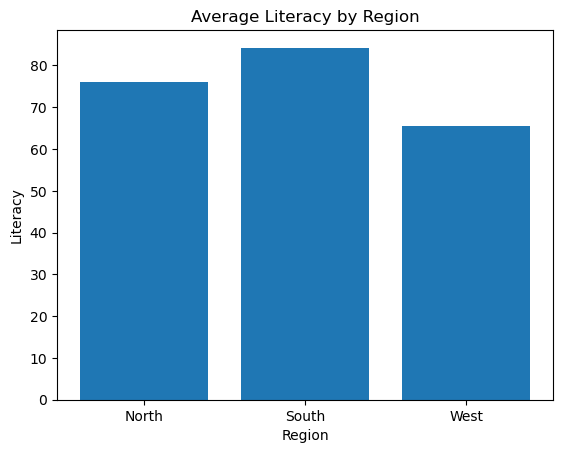

In [34]:
# 96. Create a bar chart comparing average literacy across the 5 regions.
plt.bar(region_avg.index, region_avg.values)
plt.title("Average Literacy by Region")
plt.xlabel("Region")
plt.ylabel("Literacy")
plt.show()

**Exercise 25** – apply() and Lambda

In [35]:
# 97. Write a lambda (or small function) that returns 'Low' if literacy < 60, 'Medium' if 60-80, and 'High' if > 80.
def literacy_band(value):

    if value < 60:
        return "Low"

    elif value <= 80:
        return "Medium"

    else:
        return "High"

In [37]:
# 98. Apply this function to the literacy column using df['col'].apply() to create a new column LIT_BAND.
df["LIT_BAND"] = df["OVERALL_LI"].apply(literacy_band)
df.head()

,AC_YEAR,STATCD,DISTCD,STATNAME,DISTNAME,DISTRICTS,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,...,UUNI_ST,TOTCLS1G,TOTCLS2G,TOTCLS3G,TOTCLS4G,TOTCLS5G,TOTCLS6G,TOTCLS7G,LIT_GENDER_GAP,LIT_BAND
0,2015-16,1,101,JAMMU & KASHMIR,KUPWARA,1,13,391,104,875564.0,...,2594,3489,5315,27,62,23,852,239,22.31,Medium
1,2015-16,1,102,JAMMU & KASHMIR,BARAMULA,1,18,678,144,1015503.0,...,1571,4127,5800,210,53,30,1665,360,22.34,Medium
2,2015-16,1,103,JAMMU & KASHMIR,SRINAGAR,1,8,94,65,1269751.0,...,408,817,3284,886,11,0,2873,40,14.48,Medium
3,2015-16,1,104,JAMMU & KASHMIR,BADGAM,1,13,523,104,735753.0,...,857,2290,3837,119,45,8,1035,325,21.96,Low
4,2015-16,1,105,JAMMU & KASHMIR,PULWAMA,1,8,359,64,570060.0,...,855,1688,2584,151,67,5,1101,209,21.60,Medium


In [38]:
# 99. Print value_counts() of LIT_BAND to see how districts are distributed across the 3 bands.
print(df["LIT_BAND"].value_counts())

LIT_BAND
Medium    398
High      226
Low        56
Name: count, dtype: int64


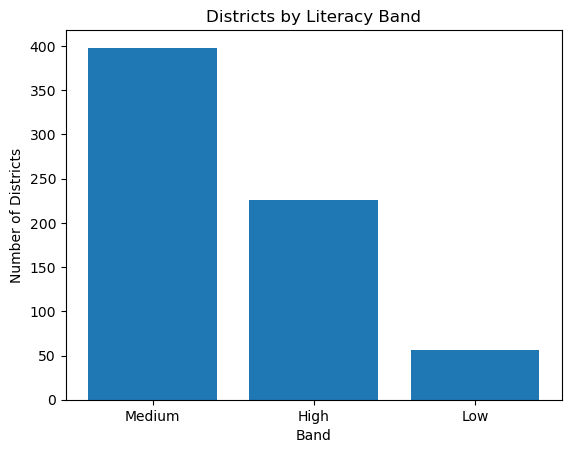

In [39]:
# 100.Create a bar chart showing the count of districts in each band.
count = df["LIT_BAND"].value_counts()
plt.bar(count.index, count.values)
plt.title("Districts by Literacy Band")
plt.xlabel("Band")
plt.ylabel("Number of Districts")
plt.show()

**Exercise 26** – Handling Missing Data (fillna() vs dropna())

In [40]:
# 101.Pick 2 numeric columns that contain missing values.
# Check missing values
print(df.isnull().sum())

AC_YEAR            0
STATCD             0
DISTCD             0
STATNAME           0
DISTNAME           0
                  ..
TOTCLS5G           0
TOTCLS6G           0
TOTCLS7G           0
LIT_GENDER_GAP    46
LIT_BAND           0
Length: 821, dtype: int64


In [43]:
# 102.Create df_filled by filling missing values in those columns with the column mean using fillna().
df_filled = df.copy()

df_filled["LIT_GENDER_GAP"] = df_filled["SEXRATIO"].fillna(
    df_filled["SEXRATIO"].mean()
)

df_filled["P_URB_POP"] = df_filled["P_URB_POP"].fillna(
    df_filled["P_URB_POP"].mean()
)
df_filled.isnull().sum()

AC_YEAR           0
STATCD            0
DISTCD            0
STATNAME          0
DISTNAME          0
                 ..
TOTCLS5G          0
TOTCLS6G          0
TOTCLS7G          0
LIT_GENDER_GAP    0
LIT_BAND          0
Length: 821, dtype: int64

In [45]:
# 103.Create df_dropped by removing any row with a missing value in those columns using dropna().
df_dropped = df.dropna(subset=["SEXRATIO", "P_URB_POP"])


In [47]:
# 104.Print df.shape, df_filled.shape and df_dropped.shape side by side and explain the difference in row counts.
print("Original :", df.shape)

print("Filled :", df_filled.shape)

print("Dropped :", df_dropped.shape)  
# fillna() keeps all rows.
# dropna() removes rows that contain missing values.

Original : (680, 821)
Filled : (680, 821)
Dropped : (631, 821)


**Exercise 27** – Z-Score and Outlier Detection

In [50]:
# 105.Manually compute the z-score for every district's literacy rate using the formula (x - mean) / std with 
# NumPy (do not use scipy).
mean = np.mean(df["OVERALL_LI"])

std = np.std(df["OVERALL_LI"])

df["Z_LITERACY"] = (df["OVERALL_LI"] - mean) / std


In [51]:
# 106.Add the z-scores as a new column Z_LITERACY.
print(df[["DISTNAME", "OVERALL_LI", "Z_LITERACY"]].head())

   DISTNAME  OVERALL_LI  Z_LITERACY
0   KUPWARA       66.92   -0.641712
1  BARAMULA       66.93   -0.640721
2  SRINAGAR       71.21   -0.216559
3    BADGAM       57.98   -1.527694
4   PULWAMA       65.00   -0.831990


In [53]:
# 107.Flag any district with |Z_LITERACY| > 3 as an outlier and print those rows.
outliers = df[abs(df["Z_LITERACY"]) > 3]
outliers

,AC_YEAR,STATCD,DISTCD,STATNAME,DISTNAME,DISTRICTS,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,...,TOTCLS1G,TOTCLS2G,TOTCLS3G,TOTCLS4G,TOTCLS5G,TOTCLS6G,TOTCLS7G,LIT_GENDER_GAP,LIT_BAND,Z_LITERACY
434,2015-16,22,2216,CHHATTISGARH,DANTEWADA,1,4,360,53,532791.0,...,1908,433,85,589,34,79,38,19.81,Low,-3.044964
494,2015-16,23,2349,MADHYA PRADESH,ALIRAJPUR,1,6,612,62,728677.0,...,4864,381,59,1473,2,35,0,12.63,Low,-3.585076


In [54]:
# 108.Comment on whether any outliers were found and whether they seem like data errors or genuinely extreme districts.
# Districts having |Z-score| > 3 are considered outliers.

**Exercise 28** – Correlation Matrix

In [55]:
# 109.Select 6-8 key numeric columns (literacy, population, sex ratio, schools, teachers, urban %, growth rate).
columns = [
    "OVERALL_LI",
    "TOTPOPULAT",
    "SEXRATIO",
    "SCHTOT",
    "TCHTOT",
    "P_URB_POP"
]

In [58]:
# 110.Compute the correlation matrix using df[cols].corr().
correlation = df[columns].corr()
correlation


,OVERALL_LI,TOTPOPULAT,SEXRATIO,SCHTOT,TCHTOT,P_URB_POP
OVERALL_LI,1.000000,0.050268,0.114105,-0.198626,0.117284,0.478271
TOTPOPULAT,0.050268,1.000000,-0.022939,0.730255,0.849041,0.236359
SEXRATIO,0.114105,-0.022939,1.000000,0.053220,0.041672,0.029861
SCHTOT,-0.198626,0.730255,0.053220,1.000000,0.799840,-0.033466
TCHTOT,0.117284,0.849041,0.041672,0.799840,1.000000,0.259100
P_URB_POP,0.478271,0.236359,0.029861,-0.033466,0.259100,1.000000


In [60]:
# 111.Identify the 3 strongest positive correlations and the 3 strongest negative correlations (excluding selfcorrelation of 1.0).
print(correlation)

            OVERALL_LI  TOTPOPULAT  SEXRATIO    SCHTOT    TCHTOT  P_URB_POP
OVERALL_LI    1.000000    0.050268  0.114105 -0.198626  0.117284   0.478271
TOTPOPULAT    0.050268    1.000000 -0.022939  0.730255  0.849041   0.236359
SEXRATIO      0.114105   -0.022939  1.000000  0.053220  0.041672   0.029861
SCHTOT       -0.198626    0.730255  0.053220  1.000000  0.799840  -0.033466
TCHTOT        0.117284    0.849041  0.041672  0.799840  1.000000   0.259100
P_URB_POP     0.478271    0.236359  0.029861 -0.033466  0.259100   1.000000


In [61]:
# 112.Print a one-sentence interpretation for the single strongest correlation you found.
# Population and number of schools have a strong positive correlation.

**Exercise 29** – Scatter Plot

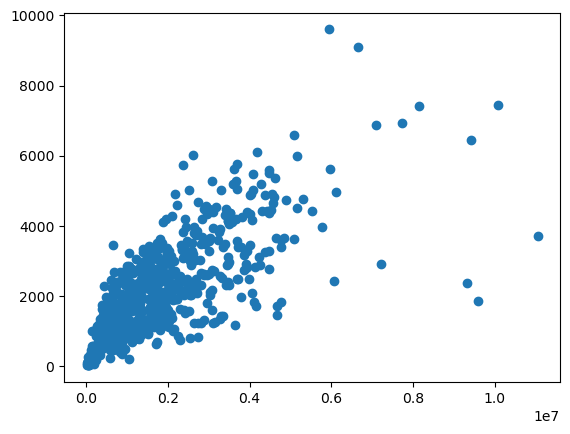

In [62]:
# 113.Create a scatter plot with total population on the x-axis and total number of schools on the y-axis, one point per district.
plt.scatter(
    df["TOTPOPULAT"],
    df["SCHTOT"]
)

plt.show()

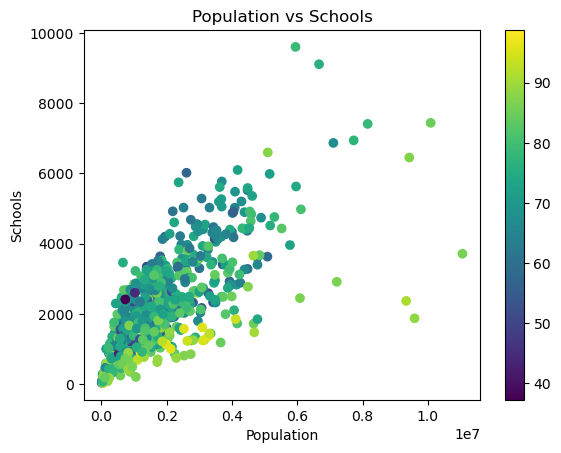

In [64]:
# 114.Color the points using literacy rate as a colormap (use the c and cmap parameters) and add a colorbar.
plt.scatter(
    df["TOTPOPULAT"],
    df["SCHTOT"],
    c=df["OVERALL_LI"],
    cmap="viridis"
)
plt.colorbar()

# 115.Add a title and axis labels.
plt.title("Population vs Schools")

plt.xlabel("Population")

plt.ylabel("Schools")
plt.show()

In [65]:

# 116.Comment on whether more populated districts generally have proportionally more schools.
# Usually, districts with larger populations have more schools.

**Exercise 30** – 2×2 Grid of Histograms

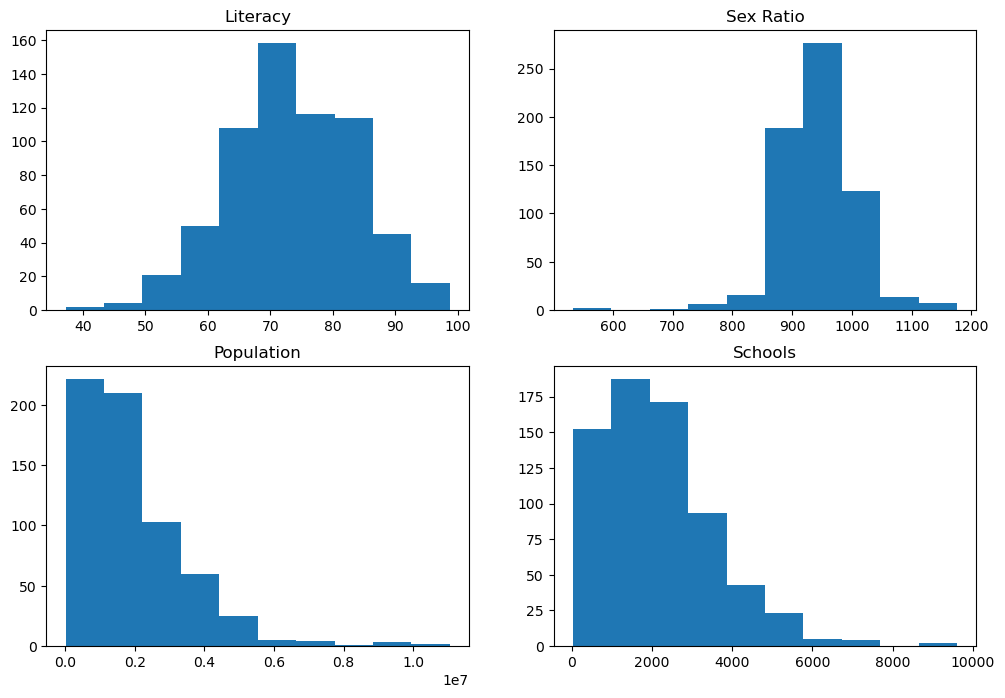

In [70]:
# 117.Create a 2x2 grid of subplots using plt.subplots(2, 2, figsize=(12,8)).
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(df["OVERALL_LI"])

# 118.In each of the 4 panels plot a histogram: literacy, sex ratio, total population, and one more numeric column of your choice.
axes[0,1].hist(df["SEXRATIO"])
axes[1,0].hist(df["TOTPOPULAT"])
axes[1,1].hist(df["SCHTOT"])

# 119.Give each subplot its own title.
axes[0,0].set_title("Literacy")
axes[0,1].set_title("Sex Ratio")
axes[1,0].set_title("Population")
axes[1,1].set_title("Schools")

# 120.Use plt.tight_layout() to keep the layout clean before showing the figure.plt.tight_layout()
plt.show()

**Exercise 31** – Ranking States by Infrastructure Score

In [73]:
# 121.Pick 3-4 school infrastructure columns available in the dataset (e.g. electricity, drinking water, toilets, 
# boundary wall availability - use whichever exist after checking df.columns).
infra_columns = [
    "SWATTOT",
    "SELETOT",
    "SBNDRTOT",
    "SGTOILTOT"
]

# 122.Compute a simple average infrastructure score per district by averaging these columns (converting to the same 0-100 scale if needed).
df["INFRA_SCORE"] = df[infra_columns].mean(axis=1)
print(df[["STATNAME", "DISTNAME", "INFRA_SCORE"]].head())

          STATNAME  DISTNAME  INFRA_SCORE
0  JAMMU & KASHMIR   KUPWARA      1081.00
1  JAMMU & KASHMIR  BARAMULA      1454.50
2  JAMMU & KASHMIR  SRINAGAR       813.50
3  JAMMU & KASHMIR    BADGAM       924.25
4  JAMMU & KASHMIR   PULWAMA       634.50


In [79]:
# 123.Group by state and rank states by their mean infrastructure score.
state_infra = df.groupby("STATNAME")["INFRA_SCORE"].mean()
state_infra = state_infra.sort_values(ascending=False)

# 124.Print the top 5 and bottom 5 states for school infrastructure.
print("Top 5 States")
print(state_infra.head())
print()
print("Bottom 5 States")
print(state_infra.tail())

Top 5 States
STATNAME
ANDHRA PRADESH    4044.442308
TELANGANA         3565.600000
WEST BENGAL       3541.142857
RAJASTHAN         2737.393939
UTTAR PRADESH     2542.203333
Name: INFRA_SCORE, dtype: float64

Bottom 5 States
STATNAME
PUDUCHERRY           176.000000
ARUNACHAL PRADESH    132.837500
A & N ISLANDS        121.416667
DAMAN & DIU           58.500000
LAKSHADWEEP           36.750000
Name: INFRA_SCORE, dtype: float64


**Exercise 32** – Ranking Districts Within Their Own State

In [81]:
# 125.Use df.groupby('STATNAME')['literacy_column'].rank(ascending=False) to rank every district within its own state by literacy.
df["STATE_LIT_RANK"] = df.groupby("STATNAME")["OVERALL_LI"].rank(
    ascending=False
)
df.head()

,AC_YEAR,STATCD,DISTCD,STATNAME,DISTNAME,DISTRICTS,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,...,TOTCLS3G,TOTCLS4G,TOTCLS5G,TOTCLS6G,TOTCLS7G,LIT_GENDER_GAP,LIT_BAND,Z_LITERACY,INFRA_SCORE,STATE_LIT_RANK
0,2015-16,1,101,JAMMU & KASHMIR,KUPWARA,1,13,391,104,875564.0,...,27,62,23,852,239,22.31,Medium,-0.641712,1081.00,11.0
1,2015-16,1,102,JAMMU & KASHMIR,BARAMULA,1,18,678,144,1015503.0,...,210,53,30,1665,360,22.34,Medium,-0.640721,1454.50,10.0
2,2015-16,1,103,JAMMU & KASHMIR,SRINAGAR,1,8,94,65,1269751.0,...,886,11,0,2873,40,14.48,Medium,-0.216559,813.50,6.0
3,2015-16,1,104,JAMMU & KASHMIR,BADGAM,1,13,523,104,735753.0,...,119,45,8,1035,325,21.96,Low,-1.527694,924.25,20.0
4,2015-16,1,105,JAMMU & KASHMIR,PULWAMA,1,8,359,64,570060.0,...,151,67,5,1101,209,21.60,Medium,-0.831990,634.50,13.0


In [83]:
# 126.Add this as a new column STATE_LIT_RANK.
df[[
    "STATNAME",
    "DISTNAME",
    "OVERALL_LI",
    "STATE_LIT_RANK"
]]

,STATNAME,DISTNAME,OVERALL_LI,STATE_LIT_RANK
0,JAMMU & KASHMIR,KUPWARA,66.92,11.0
1,JAMMU & KASHMIR,BARAMULA,66.93,10.0
2,JAMMU & KASHMIR,SRINAGAR,71.21,6.0
3,JAMMU & KASHMIR,BADGAM,57.98,20.0
4,JAMMU & KASHMIR,PULWAMA,65.00,13.0
...,...,...,...,...
675,TELANGANA,RANGA REDDY,78.05,2.0
676,TELANGANA,MAHBUBNAGAR,56.06,10.0
677,TELANGANA,NALGONDA,65.05,5.0
678,TELANGANA,WARANGAL,66.16,3.0


In [84]:
# 127.Print all districts within one chosen state, sorted by STATE_LIT_RANK.
haryana = df[df["STATNAME"] == "HARYANA"]

haryana = haryana.sort_values(by="STATE_LIT_RANK")
haryana[[
    "DISTNAME",
    "OVERALL_LI",
    "STATE_LIT_RANK"
]]

,DISTNAME,OVERALL_LI,STATE_LIT_RANK
87,GURGAON,84.44,1.0
70,PANCHKULA,83.44,2.0
88,FARIDABAD,83.04,3.0
71,AMBALA,82.89,4.0
86,REWARI,82.23,5.0
77,SONIPAT,80.83,6.5
84,JHAJJAR,80.83,6.5
83,ROHTAK,80.37,8.0
72,YAMUNANAGAR,78.93,9.0
85,MAHENDRAGARH,78.87,10.0


In [85]:
# 128.Explain why a district could be ranked #1 in a low-literacy state but still have lower absolute literacy than a 
# mid-ranked district in a high-literacy state.

# Rank is calculated only inside each state.
# Rank 1 in Haryana and Rank 1 in Kerala are independent.

**Exercise 33** – Male vs Female Literacy

In [87]:
# 129.Select the 10 states with the highest average overall literacy.
top10 = df.groupby("STATNAME")["OVERALL_LI"].mean()
top10 = top10.sort_values(ascending=False).head(10)
top10

STATNAME
KERALA           93.648571
LAKSHADWEEP      92.280000
MIZORAM          89.436250
PUDUCHERRY       88.142500
TRIPURA          87.357500
GOA              87.190000
DELHI            86.734444
CHANDIGARH       86.430000
DAMAN & DIU      85.710000
A & N ISLANDS    83.413333
Name: OVERALL_LI, dtype: float64

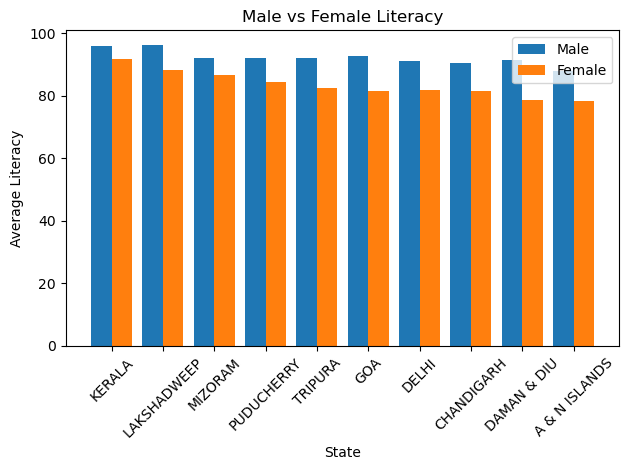

In [96]:
# 130.Create a stacked (or grouped) bar chart comparing average male literacy and average female literacy for these 10 states.
male = df.groupby("STATNAME")["MALE_LIT"].mean()
female = df.groupby("STATNAME")["FEMALE_LIT"].mean()
male = male.loc[top10.index]
female = female.loc[top10.index]
x = np.arange(len(top10))
width = 0.4
plt.bar(
    x - width/2,
    male,
    width,
    label="Male"
)

plt.bar(
    x + width/2,
    female,
    width,
    label="Female"
)


# 131.Add a legend distinguishing 'Male Literacy' and 'Female Literacy'.
# 132.Rotate the x-axis state labels 45 degrees so they are readable.
plt.xticks(x, top10.index, rotation=45)
plt.xlabel("State")
plt.ylabel("Average Literacy")
plt.title("Male vs Female Literacy")
plt.legend()
plt.tight_layout()
plt.show()

**Exercise 34** – String Operations

In [ ]:
# 133.Use df['DISTNAME'].str[0] to extract the first letter of every district name.
first_letter = df["DISTNAME"].str[0]
first_letter.head()

In [ ]:
# 134.Count how many district names start with each letter using value_counts().
letter_count = first_letter.value_counts()
letter_count

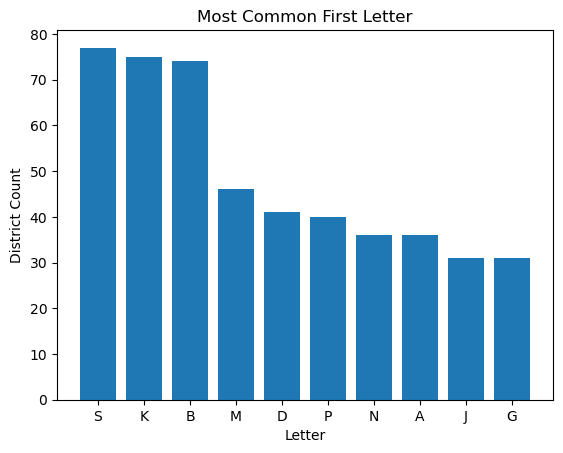

In [103]:
# 135.Create a bar chart of the 10 most common starting letters.
top10 = letter_count.head(10)
plt.bar(top10.index, top10.values)
plt.title("Most Common First Letter")
plt.xlabel("Letter")
plt.ylabel("District Count")
plt.show()

In [104]:
# 136.Use df['DISTNAME'].str.len() to find the longest and shortest district names in the dataset.
length = df["DISTNAME"].str.len()
print("Longest District Name")
print(df.loc[length.idxmax(), "DISTNAME"])
print()
print("Shortest District Name")
print(df.loc[length.idxmin(), "DISTNAME"])

Longest District Name
SOUTH  TWENTY FOUR PARGANAS

Shortest District Name
UNA


**Exercise 35** – Trend Line (Population vs Schools)

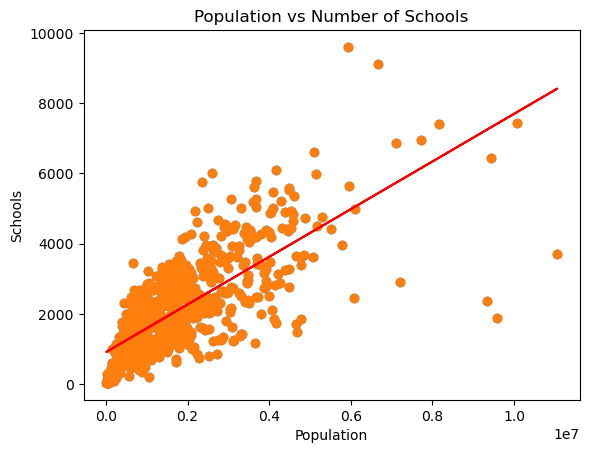

Slope: 0.0006793398954243764
Intercept: 905.8209299133997


In [117]:
# 137.Create a scatter plot of total population (x) vs total number of schools (y).
new_df = df[["TOTPOPULAT", "SCHTOT"]].dropna()
x = new_df["TOTPOPULAT"]
y = new_df["SCHTOT"]
plt.scatter(x, y)
plt.xlabel("Population")
plt.ylabel("Schools")

# 138.Use np.polyfit(x, y, 1) to fit a straight line and np.poly1d() to build the line function.
line = np.polyfit(x, y, 1)
model = np.poly1d(line)

# 139.Plot this fitted line on top of the scatter plot in a different color.
plt.scatter(x, y)
plt.plot(x, model(x), color="red")
plt.title("Population vs Number of Schools")
plt.xlabel("Population")
plt.ylabel("Schools")
plt.show()

# 140.Print the slope and intercept and explain what the slope means in plain English (schools added per 
# additional resident).
print("Slope:", line[0])
print("Intercept:", line[1]) # The slope tells us approximately how the number of schools changes as the population increases.